# Gun vs No-Gun — CNN Classifier (Colab)
Run each cell in order. Runtime > Change runtime type > GPU is recommended.

In [2]:
!pip install -q kaggle tensorflow scikit-learn matplotlib

## 1. Upload your kaggle.json (from kaggle.com/settings) then download the dataset

In [3]:
import os
os.environ['KAGGLE_API_TOKEN'] = input(" export KAGGLE_API_TOKEN=KGAT_080270b3ab28fd0d933e240db43e8eb0: ")
!pip install -q kaggle
!kaggle datasets download -d atulyakumar98/gundetection -p data_raw --unzip

 export KAGGLE_API_TOKEN=KGAT_080270b3ab28fd0d933e240db43e8eb0: 
Dataset URL: https://www.kaggle.com/datasets/atulyakumar98/gundetection
License(s): CC0-1.0
100% 250M/250M [00:14<00:00, 18.0MB/s]



## 2. Create the folder structure Keras expects
`gun` and `no_gun` images each need their own subfolder, split into `train` and `test`.

In [4]:
!mkdir -p data/train/gun data/train/no_gun data/test/gun data/test/no_gun
!ls data_raw

1000.jpg  1339.jpg  1677.jpg  2013.jpg	2351.jpg  268.jpg   325.jpg  663.jpg
1000.txt  1339.txt  1677.txt  2013.txt	2351.txt  268.txt   325.txt  663.txt
1001.jpg  133.jpg   1678.jpg  2014.jpg	2352.jpg  2690.jpg  326.jpg  664.jpg
1001.txt  133.txt   1678.txt  2014.txt	2352.txt  2690.txt  326.txt  664.txt
1002.jpg  1340.jpg  1679.jpg  2015.jpg	2353.jpg  2691.jpg  327.jpg  665.jpg
1002.txt  1340.txt  1679.txt  2015.txt	2353.txt  2691.txt  327.txt  665.txt
1003.jpg  1341.jpg  167.jpg   2016.jpg	2354.jpg  2692.jpg  328.jpg  666.jpg
1003.txt  1341.txt  167.txt   2016.txt	2354.txt  2692.txt  328.txt  666.txt
1004.jpg  1342.jpg  1680.jpg  2017.jpg	2355.jpg  2693.jpg  329.jpg  667.jpg
1004.txt  1342.txt  1680.txt  2017.txt	2355.txt  2693.txt  329.txt  667.txt
1005.jpg  1343.jpg  1681.jpg  2018.jpg	2356.jpg  2694.jpg  32.jpg   668.jpg
1005.txt  1343.txt  1681.txt  2018.txt	2356.txt  2694.txt  32.txt   668.txt
1006.jpg  1344.jpg  1682.jpg  2019.jpg	2357.jpg  2695.jpg  330.jpg  669.jpg
1006.txt  13

## 2b. Move images into place
Check the output of `!ls data_raw` above and adjust the source path/glob below to match it.
This example moves 80% of gun images to train and 20% to test — run it once the source path is correct.
You'll also need `no_gun` images (a general-objects dataset works) since the Kaggle set is gun-heavy — upload or download those into `data_raw_no_gun/` and adjust the same way.

In [5]:
 import glob, shutil, random
random.seed(42)

gun_images = glob.glob('data_raw/*.jpg')
random.shuffle(gun_images)
split = int(0.8 * len(gun_images))

for p in gun_images[:split]:
    shutil.copy(p, 'data/train/gun/')
for p in gun_images[split:]:
    shutil.copy(p, 'data/test/gun/')

print(f'{len(gun_images)} gun images copied ({split} train / {len(gun_images)-split} test)')

3000 gun images copied (2400 train / 600 test)


## 3. Build tf.data pipelines

In [6]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/train', validation_split=0.2, subset='training', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/train', validation_split=0.2, subset='validation', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

test_ds = tf.keras.utils.image_dataset_from_directory(
    'data/test', image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='binary', shuffle=False)

class_names = train_ds.class_names
print(class_names)

norm = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y: (norm(x), y)).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x,y: (norm(x), y)).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(lambda x,y: (norm(x), y)).prefetch(AUTOTUNE)

Found 2400 files belonging to 2 classes.
Using 1920 files for training.
Found 2400 files belonging to 2 classes.
Using 480 files for validation.
Found 600 files belonging to 2 classes.
['gun', 'no_gun']


## 4. Build the CNN

In [7]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    augmentation,
    tf.keras.layers.Conv2D(32,3,activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,3,activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128,3,activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(256,3,activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 5. Train

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks)

Epoch 1/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.9880 - loss: 0.0508 - val_accuracy: 1.0000 - val_loss: 0.5296 - learning_rate: 1.0000e-04
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.3372 - learning_rate: 1.0000e-04
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.1898 - learning_rate: 1.0000e-04
Epoch 4/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0904 - learning_rate: 1.0000e-04
Epoch 5/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 0.0483 - learning_rate: 1.0000e-04
Epoch 6/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - accuracy: 1.0000 - loss: 7.5516e-04 - val_accuracy: 1.0000 - val_loss: 0.0231 - learning_rate: 1.0000e-04
Epoch 7/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accu

In [15]:
import tensorflow as tf
from PIL import Image
import os, shutil, glob, random

random.seed(42)

# Purani (blurry CIFAR) no_gun images hatao
shutil.rmtree('data/train/no_gun', ignore_errors=True)
shutil.rmtree('data/test/no_gun', ignore_errors=True)
os.makedirs('data/train/no_gun', exist_ok=True)
os.makedirs('data/test/no_gun', exist_ok=True)

# Real-world photos dataset directly download karo (no tensorflow_datasets needed)
dataset_path = tf.keras.utils.get_file(
    'imagenette2-320.tgz',
    origin='https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz',
    extract=True,
    cache_dir='.'
)

# Extract hui images dhoondo
all_images = glob.glob('datasets/imagenette2-320/**/*.JPEG', recursive=True)
random.shuffle(all_images)
print(f'Found {len(all_images)} real-world images')

train_imgs = all_images[:2400]
test_imgs = all_images[2400:3000]

for i, p in enumerate(train_imgs):
    Image.open(p).convert('RGB').resize((224, 224)).save(f'data/train/no_gun/no_gun_{i}.jpg')
for i, p in enumerate(test_imgs):
    Image.open(p).convert('RGB').resize((224, 224)).save(f'data/test/no_gun/no_gun_{i}.jpg')

print('Done:', len(os.listdir('data/train/no_gun')), 'train,', len(os.listdir('data/test/no_gun')), 'test')

341663724/341663724 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step
Found 0 real-world images
Done: 0 train, 0 test


In [16]:
!find datasets -maxdepth 3 -type d

datasets
datasets/imagenette2-320_extracted
datasets/imagenette2-320_extracted/imagenette2-320
datasets/imagenette2-320_extracted/imagenette2-320/train
datasets/imagenette2-320_extracted/imagenette2-320/val


## 6. Evaluate

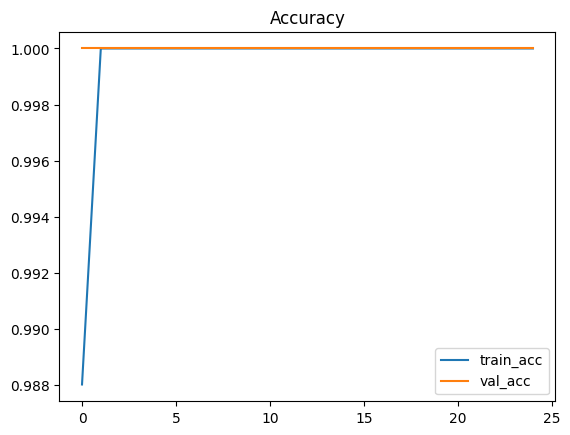

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 1.0000 - loss: 1.9725e-05
{'accuracy': 1.0, 'loss': 1.9724673620657995e-05}


In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy'); plt.show()

results = model.evaluate(test_ds, return_dict=True)
print(results)

In [17]:
import glob, random
from PIL import Image
import os

random.seed(42)

all_images = glob.glob('datasets/imagenette2-320_extracted/imagenette2-320/**/*.JPEG', recursive=True)
random.shuffle(all_images)
print(f'Found {len(all_images)} real-world images')

train_imgs = all_images[:2400]
test_imgs = all_images[2400:3000]

for i, p in enumerate(train_imgs):
    Image.open(p).convert('RGB').resize((224, 224)).save(f'data/train/no_gun/no_gun_{i}.jpg')
for i, p in enumerate(test_imgs):
    Image.open(p).convert('RGB').resize((224, 224)).save(f'data/test/no_gun/no_gun_{i}.jpg')

print('Done:', len(os.listdir('data/train/no_gun')), 'train,', len(os.listdir('data/test/no_gun')), 'test')

Found 13394 real-world images
Done: 2400 train, 600 test


In [18]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/train', validation_split=0.2, subset='training', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/train', validation_split=0.2, subset='validation', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

test_ds = tf.keras.utils.image_dataset_from_directory(
    'data/test', image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='binary', shuffle=False)

class_names = train_ds.class_names
print(class_names)

norm = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y: (norm(x), y)).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x,y: (norm(x), y)).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(lambda x,y: (norm(x), y)).prefetch(AUTOTUNE)

Found 4800 files belonging to 2 classes.
Using 3840 files for training.
Found 4800 files belonging to 2 classes.
Using 960 files for validation.
Found 1200 files belonging to 2 classes.
['gun', 'no_gun']


In [19]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    augmentation,
    tf.keras.layers.Conv2D(32,3,activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,3,activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128,3,activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(256,3,activation='relu',padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks)

Epoch 1/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 31s 230ms/step - accuracy: 0.7286 - loss: 0.5425 - val_accuracy: 0.5125 - val_loss: 0.6866 - learning_rate: 1.0000e-04
Epoch 2/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.7716 - loss: 0.4876 - val_accuracy: 0.5437 - val_loss: 0.6789 - learning_rate: 1.0000e-04
Epoch 3/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - accuracy: 0.7883 - loss: 0.4642 - val_accuracy: 0.6396 - val_loss: 0.6108 - learning_rate: 1.0000e-04
Epoch 4/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.8039 - loss: 0.4383 - val_accuracy: 0.7563 - val_loss: 0.4929 - learning_rate: 1.0000e-04
Epoch 5/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 131ms/step - accuracy: 0.8159 - loss: 0.4196 - val_accuracy: 0.8146 - val_loss: 0.4042 - learning_rate: 1.0000e-04
Epoch 6/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.8198 - loss: 0.4074 - val_accuracy: 0.8354 - val_loss: 0.3914 - learning_rate: 1.0000e-04
Epoch 7/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 13

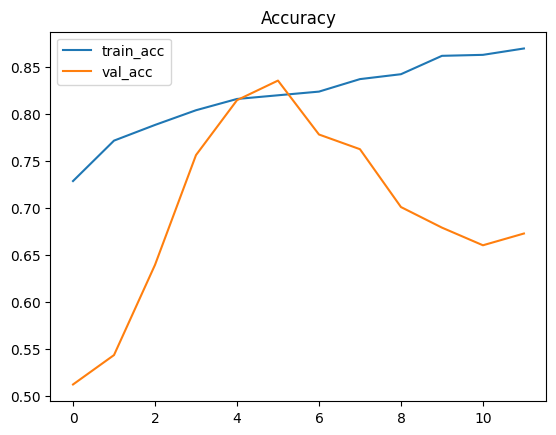

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8150 - loss: 0.4344
{'accuracy': 0.8149999976158142, 'loss': 0.4344199001789093}


In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy'); plt.show()

results = model.evaluate(test_ds, return_dict=True)
print(results)

In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_prob = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_prob.extend(preds.flatten())
    y_true.extend(labels.numpy().flatten())

y_pred = (np.array(y_prob) > 0.5).astype(int)
print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

         gun       0.81      0.83      0.82       600
      no_gun       0.82      0.80      0.81       600

    accuracy                           0.81      1200
   macro avg       0.82      0.81      0.81      1200
weighted avg       0.82      0.81      0.81      1200

[[497 103]
 [119 481]]


7. Save model and predict on a new image

In [29]:
model.save('final_model.keras')

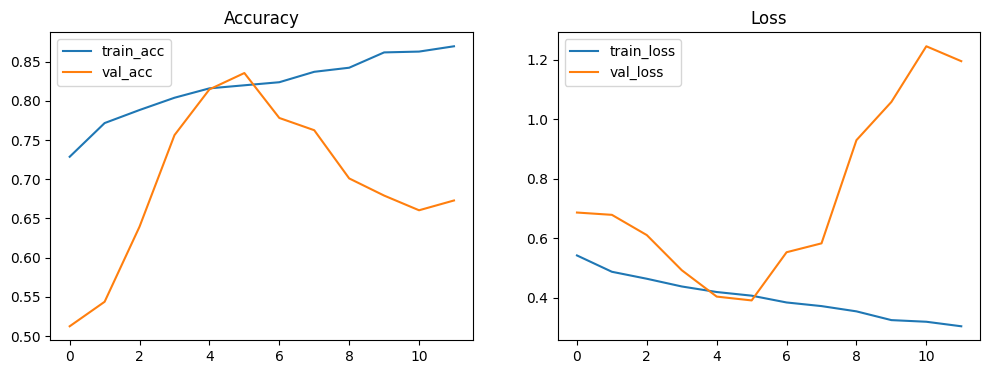

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['accuracy'], label='train_acc')
axes[0].plot(history.history['val_accuracy'], label='val_acc')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'], label='train_loss')
axes[1].plot(history.history['val_loss'], label='val_loss')
axes[1].set_title('Loss'); axes[1].legend()
plt.savefig('training_curves.png')
plt.show()
